# Assignment 3 — IMDB Sentiment & Regularisation

**DATAX504** · Due end of Week 6

Build on **Chapter 5** (regularisation / early stopping) and **Chapter 7** (Keras `compile` / `fit`, callbacks, saving). A compact Sequential stack is fine; you may use the **Functional API** if you prefer (same depth of learning either way).

## Tasks
1. Load IMDB, pad sequences, create a train / validation split
2. Train a **baseline** sentiment model and record best validation accuracy
3. Produce a **diagram** of your model architecture (see §2b)
4. Apply **two** of: L2, dropout, early stopping — report best val accuracy and name the techniques
5. Learning-rate schedule experiment (`ReduceLROnPlateau` or `LearningRateScheduler`)
6. Save the model you consider best with `model.save(...)` and check that it reloads
7. ~200-word reflection on what you learned

## Moodle fields
`a3_repo`, `a3_baseline_val`, `a3_best_val`, `a3_techniques`, `a3_model_file`

## AI disclosure (required)
Fill the table in the next cell before you submit.

## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | OpenAI Codex (GPT-5) |
| Used for | Explaining regularisation and callbacks, reviewing the code and suggesting corrections, troubleshooting the model diagram and learning-rate plot. |
| Verified how | I restarted the kernel and ran all notebook cells from top to bottom. I checked the dataset shapes, model summary, validation results, saved-model filename, and confirmed that the saved .keras model could be reloaded and evaluated on the test set. |
| Not used for | Inventing accuracy values, replacing the execution and verification of the notebook, or directly generating written conclusions. |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, regularizers, callbacks

# Optional for plot_model (Ch 7). If import fails, use model.summary() + a drawn sketch (see §2b).
try:
    from keras.utils import plot_model
except ImportError:
    plot_model = None

keras.utils.set_random_seed(42)

## 1. Load & prepare IMDB

Hints (fill in the blanks):
- `keras.datasets.imdb.load_data(num_words=...)`
- pad both train and test with `keras.utils.pad_sequences(..., maxlen=...)`
- hold out the **first 10_000** padded training examples as validation (Ch 4 / 5 style split)
- keep the rest of the training set for fitting

In [2]:
max_features = 10000
max_len = 500

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

# TODO: pad sequences so every review has length max_len
x_train = keras.utils.pad_sequences(x_train, maxlen=max_len)
x_test = keras.utils.pad_sequences(x_test, maxlen=max_len)

# TODO: validation split — first 10_000 samples for val, remainder for train
x_val = x_train[:10000]
y_val = y_train[:10000]

x_train = x_train[10000:]
y_train = y_train[10000:]

print("train:", x_train.shape, y_train.shape)
print("val:  ", x_val.shape, y_val.shape)
print("test: ", x_test.shape, y_test.shape)

train: (15000, 500) (15000,)
val:   (10000, 500) (10000,)
test:  (25000, 500) (25000,)


## 2. Baseline model

Suggested architecture (you may change widths if you document why):
1. `Embedding(max_features, 32, input_length=max_len)` — turns token ids into vectors
2. `GlobalAveragePooling1D()` — mean over the time axis
3. `Dense(32, activation="relu")`
4. `Dense(1, activation="sigmoid")` — binary sentiment

Then:
- `compile` with a suitable optimizer, **binary cross-entropy** loss, and accuracy metric
- `fit` with `validation_data=(x_val, y_val)` for ~10 epochs (batch size is your choice; 512 is common for this data)
- record the **best** validation accuracy over epochs for Moodle `a3_baseline_val`

In [3]:
def build_baseline():
    # TODO: build Sequential (or Functional) model, compile, return it
    model = keras.Sequential([
        layers.Input(shape=(max_len,), dtype="int32"),
        layers.Embedding(max_features, 32),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


baseline = build_baseline()

# TODO: fit and keep the History object
hist_baseline = baseline.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1,
)

# TODO: best validation accuracy across epochs
baseline_val_acc = float(max(hist_baseline.history["val_accuracy"]))

print(
    f"Baseline best val accuracy "
    f"(Moodle a3_baseline_val): {baseline_val_acc:.4f}"
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5647 - loss: 0.6908 - val_accuracy: 0.5449 - val_loss: 0.6882
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6152 - loss: 0.6802 - val_accuracy: 0.5944 - val_loss: 0.6722
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6754 - loss: 0.6557 - val_accuracy: 0.6174 - val_loss: 0.6444
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6991 - loss: 0.6159 - val_accuracy: 0.6461 - val_loss: 0.6068
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7507 - loss: 0.5646 - val_accuracy: 0.7815 - val_loss: 0.5421
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7899 - loss: 0.5102 - val_accuracy: 0.8072 - val_loss: 0.4921
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8240 - loss: 0.4592 - val_accuracy: 0.8211 - val_loss: 0.4535
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8402 - loss: 0.4199 - val_accuracy: 0.8387 - val_loss

## 2b. Diagram of your architecture (required)

You *can* do this with the tools from **Chapter 7 / Week 5**:

```python
keras.utils.plot_model(
    baseline,                      # or your regularised model
    to_file="imdb_model.png",      # commit this image to your repo
    show_shapes=True,
    show_layer_names=True,
)
```

Also print `model.summary()` so layer shapes appear in the notebook.

**If `plot_model` fails** (missing Graphviz / pydot on your machine):
1. Keep a full `model.summary()` output in the notebook, and
2. Add a short markdown diagram or hand-drawn photo of the stack (Embedding → … → sigmoid).

Either way, a reader should see the full forward path without reading all of your code.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 963,269 (3.67 MB)

 Trainable params: 321,089 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 642,180 (2.45 MB)

Wrote imdb_model.png


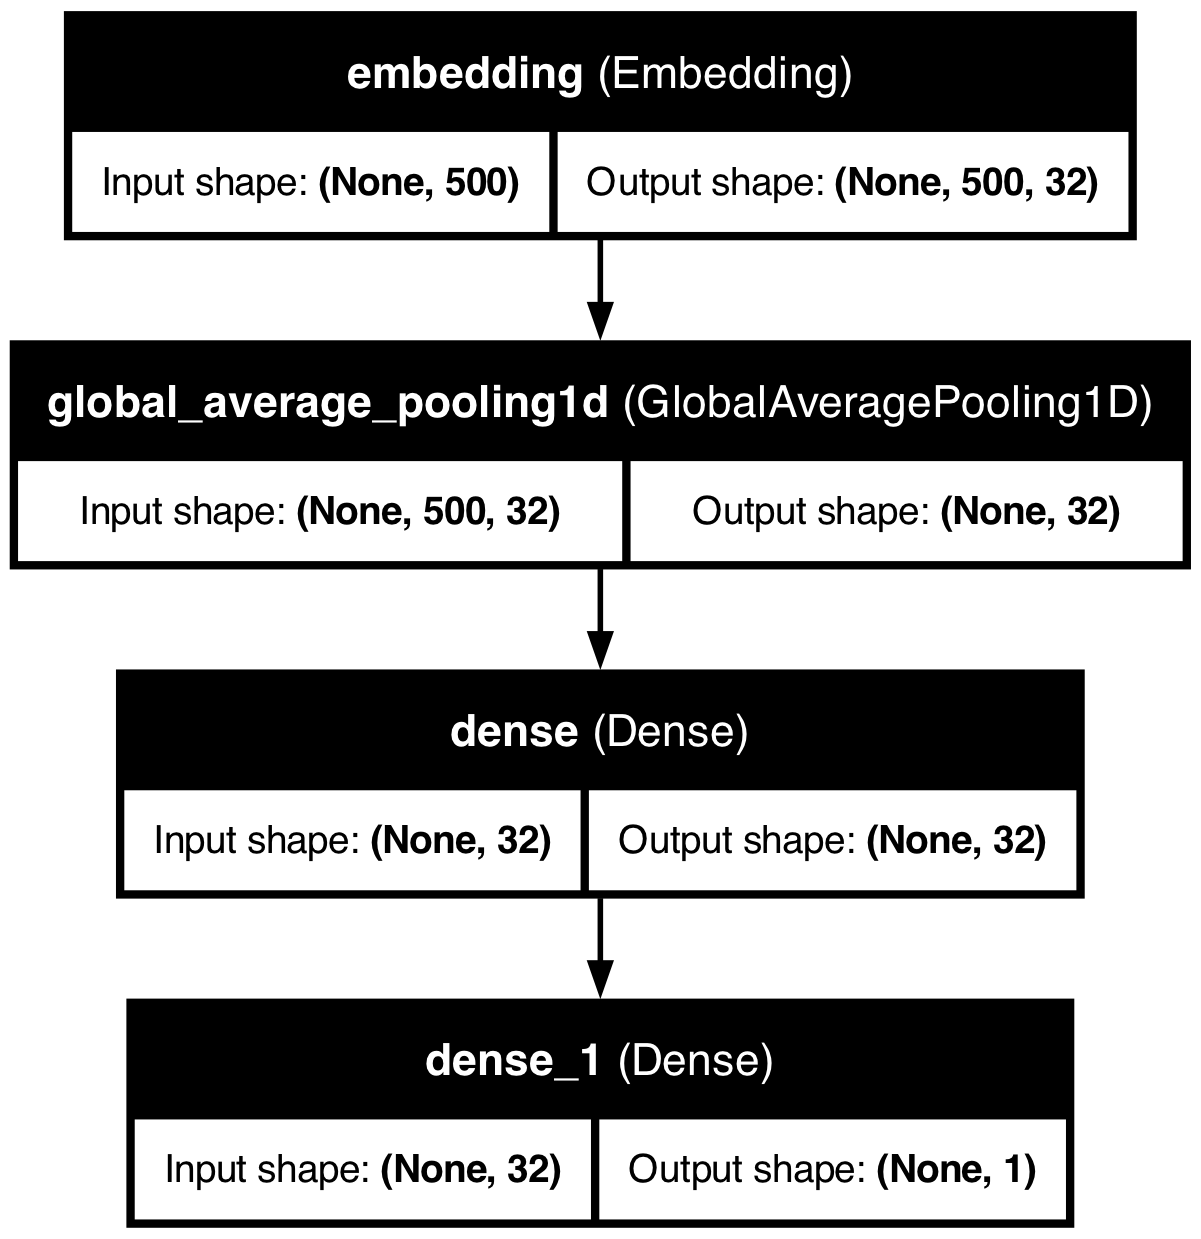

In [4]:
# TODO: print architecture summary
baseline.summary()

# TODO: save a DAG figure when Graphviz/pydot are available
DIAGRAM_FILE = "imdb_model.png"
if plot_model is not None:
    try:
        plot_model(
            baseline,
            to_file=DIAGRAM_FILE,
            show_shapes=True,
            show_layer_names=True,
        )
        print(f"Wrote {DIAGRAM_FILE}")
        
        from IPython.display import Image, display
        display(Image(DIAGRAM_FILE))
    except Exception as e:
        print("plot_model failed:", e)
else:
    print("plot_model unavailable")

## 3. Regularised model

Choose **exactly two** (or more if curious, but Moodle asks for two) of:

| Technique | Typical hook |
|-----------|----------------|
| L2 | `kernel_regularizer=regularizers.l2(...)` on a Dense layer |
| Dropout | `layers.Dropout(rate)` after a Dense / before the output |
| Early stopping | `callbacks.EarlyStopping(monitor="val_loss", patience=..., restore_best_weights=True)` |

Hints:
- Set boolean flags below so you can print which techniques you used
- `compile` again after building the stack
- Pass a **list of callbacks** into `fit` (empty list if you did not pick early stopping)
- Train long enough that early stopping might fire (e.g. more epochs than the baseline)
- Best val accuracy → Moodle `a3_best_val`; names → `a3_techniques`

In [5]:
USE_L2 = False
USE_DROPOUT = True
USE_EARLY_STOP = True


def build_regularised():
    model = keras.Sequential([
        layers.Input(shape=(max_len,), dtype="int32"),
        layers.Embedding(max_features, 32),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


reg_model = build_regularised()

early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

hist_reg = reg_model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=1,
)

best_val_acc = float(max(hist_reg.history["val_accuracy"]))

techniques = []
if USE_L2:
    techniques.append("L2")
if USE_DROPOUT:
    techniques.append("dropout")
if USE_EARLY_STOP:
    techniques.append("early stopping")

print(f"Techniques: {', '.join(techniques)}")
print(f"Regularised best val accuracy: {best_val_acc:.4f}")

assert len(techniques) >= 2

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5189 - loss: 0.6926 - val_accuracy: 0.5289 - val_loss: 0.6914
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5633 - loss: 0.6892 - val_accuracy: 0.5658 - val_loss: 0.6861
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6018 - loss: 0.6800 - val_accuracy: 0.6024 - val_loss: 0.6735
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6574 - loss: 0.6611 - val_accuracy: 0.6474 - val_loss: 0.6474
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6956 - loss: 0.6281 - val_accuracy: 0.6595 - val_loss: 0.6144
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7311 - loss: 0.5835 - val_accuracy: 0.7898 - val_loss: 0.5538
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7687 - loss: 0.5346 - val_accuracy: 0.8170 - val_loss: 0.5047
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8036 - loss: 0.4871 - val_accuracy: 0.8219 - val_loss

## 4. Learning-rate schedule

Week 5 / Ch 7 callback: try **`ReduceLROnPlateau`** (shrink LR when `val_loss` stalls)
or a custom **`LearningRateScheduler`**.

Hints:
- Start from the baseline or your regularised architecture (`build_baseline()` is fine)
- Put the schedule callback in the `callbacks=[...]` list for `fit`
- After training, plot the learning-rate history if present (`hist.history.get("lr", [])` for ReduceLROnPlateau)
- Short markdown below: which schedule, why those hyperparameters, what you observed

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5427 - loss: 0.6921 - val_accuracy: 0.5433 - val_loss: 0.6899 - learning_rate: 0.0010
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5963 - loss: 0.6848 - val_accuracy: 0.5672 - val_loss: 0.6799 - learning_rate: 0.0010
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6476 - loss: 0.6676 - val_accuracy: 0.6562 - val_loss: 0.6554 - learning_rate: 0.0010
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6969 - loss: 0.6366 - val_accuracy: 0.6742 - val_loss: 0.6213 - learning_rate: 0.0010
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7409 - loss: 0.5921 - val_accuracy: 0.6707 - val_loss: 0.5880 - learning_rate: 0.0010
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7587 - loss: 0.5454 - val_accuracy: 0.7933 - val_loss: 0.5241 - learning_rate: 0.0010
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7955 - loss: 0.4969 - val_accuracy:

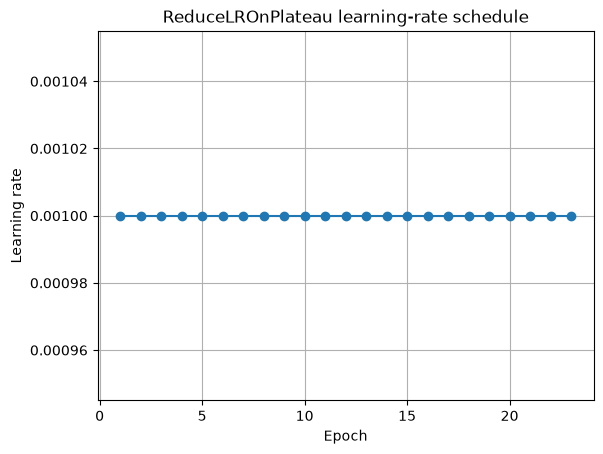

In [6]:
lr_model = build_baseline()  # or rebuild your regularised architecture

# TODO: choose one schedule callback, e.g.
lr_cb = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1,
)

lr_early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=4,
    restore_best_weights=True,
    verbose=1,
)


class LearningRateLogger(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs["learning_rate"] = float(
            keras.ops.convert_to_numpy(
                self.model.optimizer.learning_rate
            )
        )

hist_lr = lr_model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[
        lr_cb,
        lr_early_stop,
        LearningRateLogger(),
    ],
    verbose=1,
)

lr_best_val_acc = float(max(hist_lr.history["val_accuracy"]))
print(f"LR experiment best val accuracy: {lr_best_val_acc:.4f}")

# TODO: plot LR vs epoch when the history key exists
lrs = hist_lr.history.get("learning_rate", [])

if lrs:
    plt.plot(range(1, len(lrs) + 1), lrs, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title("ReduceLROnPlateau learning-rate schedule")
    plt.grid(True)
    plt.show()

**LR experiment notes** (a few sentences):

- Schedule used:I used ReduceLROnPlateau, monitoring validation loss with a reduction factor of 0.5 and a minimum learning rate of 1e-6.
- Observed effect on val curves / final accuracy:The experiment achieved a best validation accuracy of 0.8730, compared with 0.8718 for the regularised model without the learning-rate callback. However, the plotted learning rate remained at 0.001 throughout training because the plateau condition was not met before early stopping occurred. Therefore, the small difference in accuracy cannot confidently be attributed to a learning-rate reduction.
- Would you keep this schedule for a real project?
  I would not keep these exact settings without further tuning. I would adjust patience or min_delta, or test a scheduled decay that changes the learning rate at predetermined epochs.

## 5. Save best model

Hints (Ch 7):
- Pick one of baseline / regularised / LR-tuned
- `best_model.save("something.keras")` — full architecture + weights
- `keras.models.load_model(...)` and `evaluate` on **test** once (do not retune on test)
- Commit the `.keras` file and the diagram PNG to your GitHub repo
- Filename → Moodle `a3_model_file`

In [7]:
MODEL_FILE = "imdb_sentiment_best.keras"  # Moodle a3_model_file

if lr_best_val_acc > best_val_acc:
    best_model = lr_model
    best_tuned_val_acc = lr_best_val_acc
    selected_model_name = "regularised model with LR schedule"
else:
    best_model = reg_model
    best_tuned_val_acc = best_val_acc
    selected_model_name = "regularised model"

best_model.save(MODEL_FILE)

# TODO: reload and evaluate on the test set once
loaded = keras.models.load_model(MODEL_FILE)
test_loss, test_acc = loaded.evaluate(
    x_test,
    y_test,
    verbose=0,
)

print(f"Selected model: {selected_model_name}")
print(f"Best tuned validation accuracy: {best_tuned_val_acc:.4f}")
print(f"Saved model filename: {MODEL_FILE}")
print(f"Reloaded model test accuracy: {test_acc:.4f}")

Selected model: regularised model with LR schedule
Best tuned validation accuracy: 0.8730
Saved model filename: imdb_sentiment_best.keras
Reloaded model test accuracy: 0.8695


## 6. What did you learn?

Write ~200 words in the cell below (or paste the same text into Moodle if asked).
Cover: baseline vs regularised result, whether a technique hurt or helped, LR schedule takeaway, and one thing you would try next.

*Your reflection (~200 words).*

In this assignment, I investigated how regularisation strategies and training callbacks can optimise the performance of a sentiment-classification model. My baseline model achieved a peak validation accuracy of 0.8525. After integrating dropout and an early-stopping callback, validation accuracy rose to 0.8718, corresponding to a 1.93-percentage-point improvement. Dropout reduced the model's over-dependence on specific neuron activations, whereas early stopping eliminated unnecessary training iterations and restored the weights from the best-performing epoch.

The learning-rate experiment yielded the highest validation accuracy of 0.8730. However, ReduceLROnPlateau did not decrease the learning rate, which remained at 0.001, because validation loss continued to satisfy the improvement criterion before early stopping was triggered. Therefore, the minor performance gain is not evidence of the scheduler's effectiveness and may result from normal run-to-run variation.

I selected this model based on validation accuracy, saved it as imdb_sentiment_best.keras, and reloaded it successfully, obtaining a test accuracy of 0.8695. This practical experience emphasised that validation data should be used for model selection, while test data should only be used for final assessment. For further experiments, I would test multiple dropout rates, apply L2 regularisation, and tune the scheduler's patience and minimum-change threshold.